# Student Marks Predictor

Predicted Score for 1.2 hours of study is:  36.36
Mean Squared Error: 0.9508927530360135
R^2 Score: 0.9966179829598963


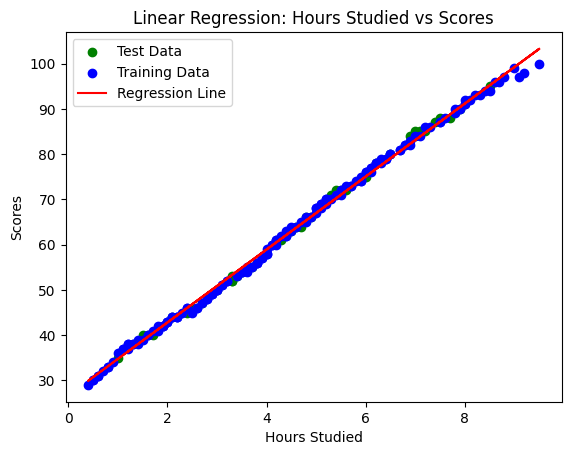

In [36]:
# import necessary libraries
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
data = pd.read_csv('student_scores.csv')

x =data[['Hours']]
y = data['Score']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

# train the model
model = LinearRegression()
model.fit(x_train, y_train)

try:
    hours_input = float(input("Enter the number of hours studied: "))
except ValueError:
    print("Invalid input. Please enter a number!") 
    exit()  

input_data = pd.DataFrame([[hours_input]], columns=['Hours'])

prediction = model.predict(input_data)[0]
print(f"Predicted Score for {hours_input} hours of study is: {prediction: .2f}")

mse = mean_squared_error(y_test, model.predict(x_test))
print(f"Mean Squared Error: {mse}")  

r2 = r2_score(y_test, model.predict(x_test))
print(f"R^2 Score: {r2}")


plt.scatter(x_test, y_test, color='green', label='Test Data')
plt.scatter(x_train, y_train, color='blue', label='Training Data')
plt.plot(x, model.predict(x), color='red', label='Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Scores')
plt.title('Linear Regression: Hours Studied vs Scores')
plt.legend()
plt.show()